## Step 1: Imports & Setup

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cuda


## Step 2: Load & Visualize Fashion-MNIST

100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.75MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 64.8MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 30.9MB/s]


Total training images : 60000
Number of batches     : 469


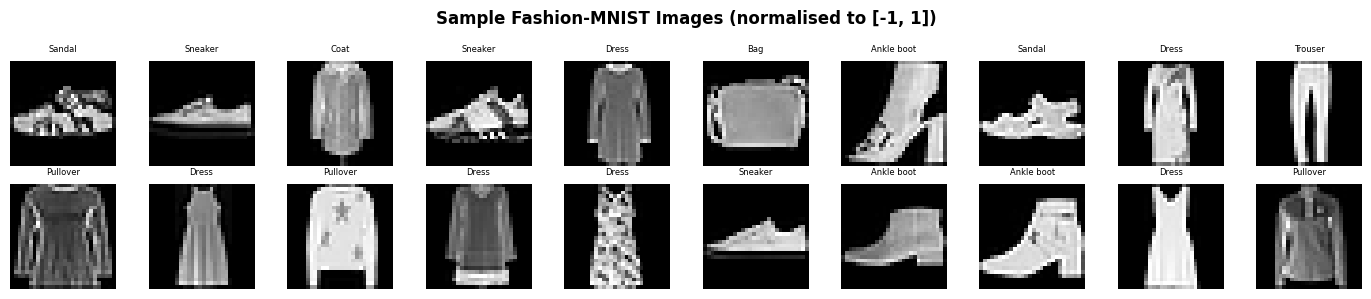

In [ ]:
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]
NUM_CLASSES = 10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, transform=transform, download=True
)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

print(f'Total training images : {len(train_dataset)}')
print(f'Number of batches     : {len(train_loader)}')

images, labels = next(iter(train_loader))

plt.figure(figsize=(14, 3))
plt.suptitle('Sample Fashion-MNIST Images (normalised to [-1, 1])', fontsize=12, fontweight='bold')
for i in range(20):
    plt.subplot(2, 10, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap='gray')
    plt.title(CLASS_NAMES[labels[i].item()], fontsize=6)
    plt.axis('off')
plt.tight_layout()
plt.show()

## Step 3: Standard GAN (Baseline)

In [ ]:
LATENT_DIM = 100
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256, momentum=0.8),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512, momentum=0.8),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(1024, momentum=0.8),

            nn.Linear(1024, 28 * 28),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img.view(img.size(0), 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)


generator     = Generator(LATENT_DIM).to(DEVICE)
discriminator = Discriminator().to(DEVICE)

g_params = sum(p.numel() for p in generator.parameters())
d_params = sum(p.numel() for p in discriminator.parameters())
print(f'GAN Generator parameters     : {g_params:,}')
print(f'GAN Discriminator parameters : {d_params:,}')

GAN Generator parameters     : 1,489,936
GAN Discriminator parameters : 533,505


## Step 4: Train Standard GAN

In [ ]:
criterion   = nn.BCELoss()
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_G = torch.optim.Adam(generator.parameters(),     lr=0.0002, betas=(0.5, 0.999))

NUM_EPOCHS   = 50
fixed_noise  = torch.randn(16, LATENT_DIM, device=DEVICE)

GAN_G_losses, GAN_D_losses = [], []
GAN_D_real_accs, GAN_D_fake_accs = [], []

print(f'Training standard GAN for {NUM_EPOCHS} epochs on Fashion-MNIST...')
for epoch in range(1, NUM_EPOCHS + 1):
    ep_G = ep_D = ep_ra = ep_fa = 0.0
    n_batches = 0

    for real_images, _ in train_loader:
        bs = real_images.size(0)
        real_images = real_images.to(DEVICE)
        real_labels = torch.ones(bs, 1, device=DEVICE)
        fake_labels = torch.zeros(bs, 1, device=DEVICE)

        optimizer_D.zero_grad()
        out_real = discriminator(real_images)
        loss_D_real = criterion(out_real, real_labels)

        z = torch.randn(bs, LATENT_DIM, device=DEVICE)
        fake_images = generator(z).detach()
        out_fake = discriminator(fake_images)
        loss_D_fake = criterion(out_fake, fake_labels)

        loss_D = (loss_D_real + loss_D_fake) / 2
        loss_D.backward()
        optimizer_D.step()

        optimizer_G.zero_grad()
        z = torch.randn(bs, LATENT_DIM, device=DEVICE)
        gen_images = generator(z)
        out_gen = discriminator(gen_images)
        loss_G = criterion(out_gen, real_labels)
        loss_G.backward()
        optimizer_G.step()

        ep_G  += loss_G.item()
        ep_D  += loss_D.item()
        ep_ra += (out_real > 0.5).float().mean().item()
        ep_fa += (out_fake < 0.5).float().mean().item()
        n_batches += 1

    avg_G  = ep_G  / n_batches
    avg_D  = ep_D  / n_batches
    avg_ra = ep_ra / n_batches
    avg_fa = ep_fa / n_batches

    GAN_G_losses.append(avg_G)
    GAN_D_losses.append(avg_D)
    GAN_D_real_accs.append(avg_ra)
    GAN_D_fake_accs.append(avg_fa)

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch [{epoch:3d}/{NUM_EPOCHS}]  '
              f'D_loss: {avg_D:.4f}  G_loss: {avg_G:.4f}  '
              f'D(real): {avg_ra:.3f}  D(fake): {avg_fa:.3f}')

print('\nStandard GAN training complete!')

Training standard GAN for 50 epochs on Fashion-MNIST...
Epoch [  1/50]  D_loss: 0.4503  G_loss: 1.2367  D(real): 0.833  D(fake): 0.724
Epoch [ 10/50]  D_loss: 0.6824  G_loss: 0.7607  D(real): 0.518  D(fake): 0.603
Epoch [ 20/50]  D_loss: 0.6887  G_loss: 0.7311  D(real): 0.511  D(fake): 0.569
Epoch [ 30/50]  D_loss: 0.6904  G_loss: 0.7176  D(real): 0.502  D(fake): 0.554
Epoch [ 40/50]  D_loss: 0.6914  G_loss: 0.7084  D(real): 0.500  D(fake): 0.549
Epoch [ 50/50]  D_loss: 0.6910  G_loss: 0.7088  D(real): 0.506  D(fake): 0.545

Standard GAN training complete!


## Step 5: Evaluate Standard GAN — Generated Images

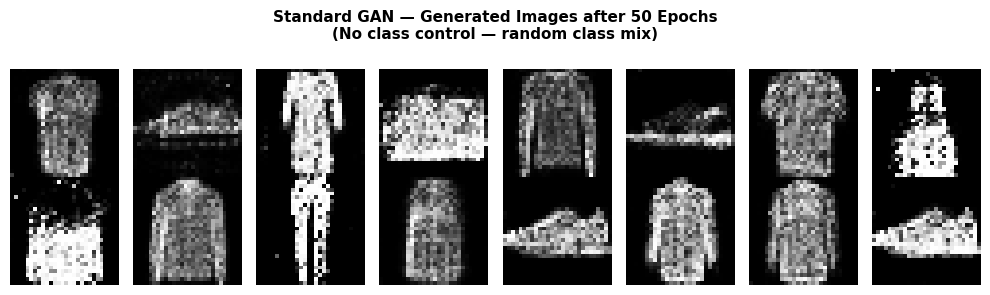

In [ ]:
generator.eval()
with torch.no_grad():
    z = torch.randn(16, LATENT_DIM, device=DEVICE)
    gan_generated = generator(z).cpu()

plt.figure(figsize=(10, 3))
plt.suptitle(f'Standard GAN — Generated Images after {NUM_EPOCHS} Epochs\n'
             '(No class control — random class mix)', fontsize=11, fontweight='bold')
for i in range(16):
    plt.subplot(2, 8, i + 1)
    plt.imshow(gan_generated[i].squeeze().numpy(), cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Step 6: Standard GAN — Loss Curves

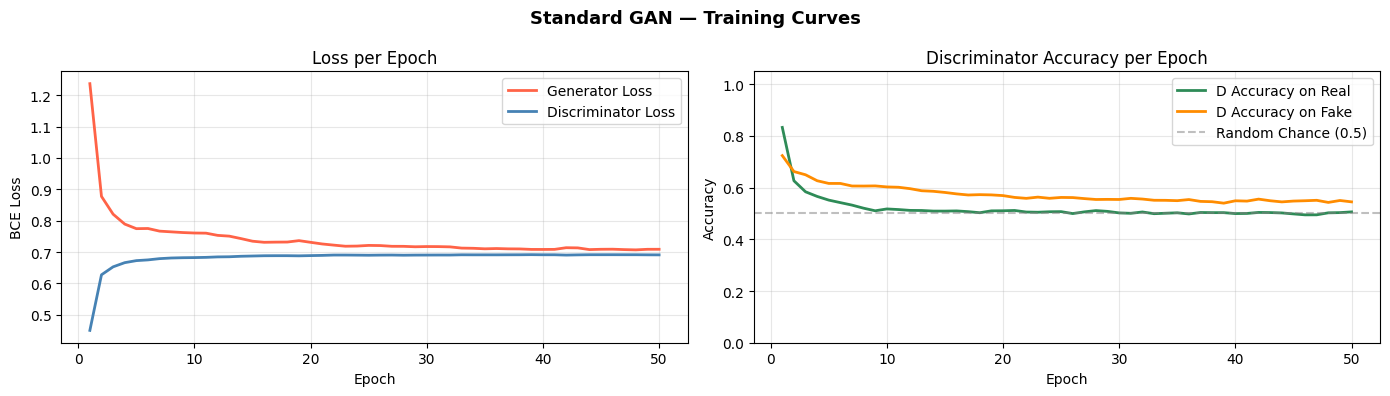

Final Generator Loss     : 0.7088
Final Discriminator Loss : 0.6910
D Accuracy on Real       : 0.506
D Accuracy on Fake       : 0.545


In [ ]:
epochs_range = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Standard GAN — Training Curves', fontsize=13, fontweight='bold')

ax1.plot(epochs_range, GAN_G_losses, label='Generator Loss',     color='tomato',    linewidth=2)
ax1.plot(epochs_range, GAN_D_losses, label='Discriminator Loss', color='steelblue', linewidth=2)
ax1.set_title('Loss per Epoch')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, GAN_D_real_accs, label='D Accuracy on Real', color='seagreen',  linewidth=2)
ax2.plot(epochs_range, GAN_D_fake_accs, label='D Accuracy on Fake', color='darkorange', linewidth=2)
ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random Chance (0.5)')
ax2.set_title('Discriminator Accuracy per Epoch')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.05)
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final Generator Loss     : {GAN_G_losses[-1]:.4f}')
print(f'Final Discriminator Loss : {GAN_D_losses[-1]:.4f}')
print(f'D Accuracy on Real       : {GAN_D_real_accs[-1]:.3f}')
print(f'D Accuracy on Fake       : {GAN_D_fake_accs[-1]:.3f}')

## Step 7: Conditional GAN (cGAN)

In [ ]:
class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim=100, num_classes=10):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.model = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256, momentum=0.8),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512, momentum=0.8),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(1024, momentum=0.8),

            nn.Linear(1024, 28 * 28),
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_input = self.label_emb(labels)
        x = torch.cat([z, label_input], dim=1)
        img = self.model(x)
        return img.view(img.size(0), 1, 28, 28)

class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, 28 * 28)

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2 * 28 * 28, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        label_map = self.label_emb(labels)
        label_map = label_map.view(img.size(0), 1, 28, 28)
        x = torch.cat([img, label_map], dim=1)
        return self.model(x)


cgan_generator     = ConditionalGenerator(LATENT_DIM, NUM_CLASSES).to(DEVICE)
cgan_discriminator = ConditionalDiscriminator(NUM_CLASSES).to(DEVICE)

cg_params = sum(p.numel() for p in cgan_generator.parameters())
cd_params = sum(p.numel() for p in cgan_discriminator.parameters())
print(f'cGAN Generator parameters     : {cg_params:,}')
print(f'cGAN Discriminator parameters : {cd_params:,}')

cGAN Generator parameters     : 1,492,596
cGAN Discriminator parameters : 942,753


## Step 8: Train Conditional GAN

In [ ]:
cgan_criterion   = nn.BCELoss()
cgan_optimizer_D = torch.optim.Adam(cgan_discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
cgan_optimizer_G = torch.optim.Adam(cgan_generator.parameters(),     lr=0.0002, betas=(0.5, 0.999))

fixed_noise_c = torch.randn(NUM_CLASSES * 2, LATENT_DIM, device=DEVICE)
fixed_labels  = torch.arange(NUM_CLASSES, device=DEVICE).repeat(2)

CGAN_G_losses, CGAN_D_losses = [], []
CGAN_D_real_accs, CGAN_D_fake_accs = [], []

print(f'Training Conditional GAN for {NUM_EPOCHS} epochs on Fashion-MNIST...')
for epoch in range(1, NUM_EPOCHS + 1):
    ep_G = ep_D = ep_ra = ep_fa = 0.0
    n_batches = 0

    for real_images, real_cls in train_loader:
        bs = real_images.size(0)
        real_images = real_images.to(DEVICE)
        real_cls    = real_cls.to(DEVICE)
        real_labels = torch.ones(bs, 1, device=DEVICE)
        fake_labels = torch.zeros(bs, 1, device=DEVICE)

        cgan_optimizer_D.zero_grad()
        out_real = cgan_discriminator(real_images, real_cls)
        loss_D_real = cgan_criterion(out_real, real_labels)

        z         = torch.randn(bs, LATENT_DIM, device=DEVICE)
        fake_cls  = torch.randint(0, NUM_CLASSES, (bs,), device=DEVICE)
        fake_imgs = cgan_generator(z, fake_cls).detach()
        out_fake  = cgan_discriminator(fake_imgs, fake_cls)
        loss_D_fake = cgan_criterion(out_fake, fake_labels)

        loss_D = (loss_D_real + loss_D_fake) / 2
        loss_D.backward()
        cgan_optimizer_D.step()

        cgan_optimizer_G.zero_grad()
        z        = torch.randn(bs, LATENT_DIM, device=DEVICE)
        gen_cls  = torch.randint(0, NUM_CLASSES, (bs,), device=DEVICE)
        gen_imgs = cgan_generator(z, gen_cls)
        out_gen  = cgan_discriminator(gen_imgs, gen_cls)
        loss_G   = cgan_criterion(out_gen, real_labels)
        loss_G.backward()
        cgan_optimizer_G.step()

        ep_G  += loss_G.item()
        ep_D  += loss_D.item()
        ep_ra += (out_real > 0.5).float().mean().item()
        ep_fa += (out_fake < 0.5).float().mean().item()
        n_batches += 1

    avg_G  = ep_G  / n_batches
    avg_D  = ep_D  / n_batches
    avg_ra = ep_ra / n_batches
    avg_fa = ep_fa / n_batches

    CGAN_G_losses.append(avg_G)
    CGAN_D_losses.append(avg_D)
    CGAN_D_real_accs.append(avg_ra)
    CGAN_D_fake_accs.append(avg_fa)

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch [{epoch:3d}/{NUM_EPOCHS}]  '
              f'D_loss: {avg_D:.4f}  G_loss: {avg_G:.4f}  '
              f'D(real): {avg_ra:.3f}  D(fake): {avg_fa:.3f}')

print('\nConditional GAN training complete!')

Training Conditional GAN for 50 epochs on Fashion-MNIST...
Epoch [  1/50]  D_loss: 0.2888  G_loss: 2.9257  D(real): 0.861  D(fake): 0.894
Epoch [ 10/50]  D_loss: 0.6194  G_loss: 1.0575  D(real): 0.626  D(fake): 0.663
Epoch [ 20/50]  D_loss: 0.6897  G_loss: 0.7220  D(real): 0.500  D(fake): 0.571
Epoch [ 30/50]  D_loss: 0.6920  G_loss: 0.7070  D(real): 0.495  D(fake): 0.549
Epoch [ 40/50]  D_loss: 0.6926  G_loss: 0.6995  D(real): 0.484  D(fake): 0.544
Epoch [ 50/50]  D_loss: 0.6931  G_loss: 0.6969  D(real): 0.482  D(fake): 0.538

Conditional GAN training complete!


## Step 9: Evaluate cGAN — Class-Conditioned Generation

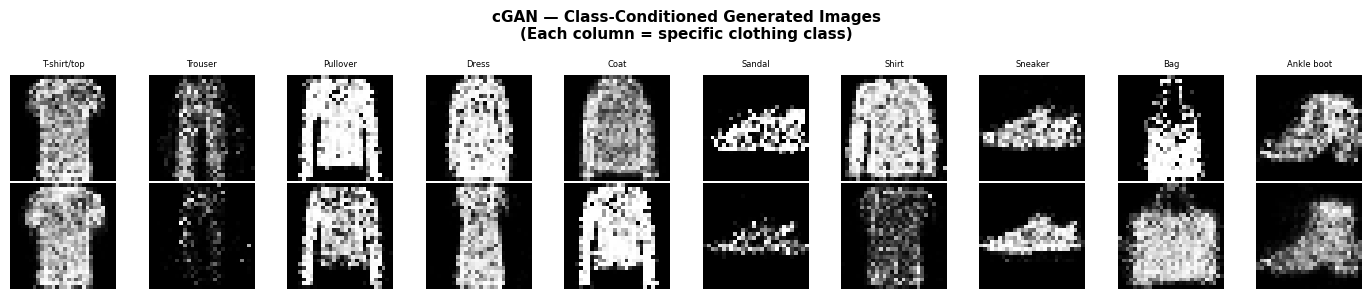

In [ ]:
cgan_generator.eval()
with torch.no_grad():
    cgan_generated = cgan_generator(fixed_noise_c, fixed_labels).cpu()

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(14, 3))
fig.suptitle('cGAN — Class-Conditioned Generated Images\n'
             '(Each column = specific clothing class)',
             fontsize=11, fontweight='bold')

for row in range(2):
    for col in range(NUM_CLASSES):
        idx = row * NUM_CLASSES + col
        axes[row, col].imshow(cgan_generated[idx].squeeze().numpy(), cmap='gray')
        if row == 0:
            axes[row, col].set_title(CLASS_NAMES[col], fontsize=6)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## Step 10: cGAN — Loss Curves

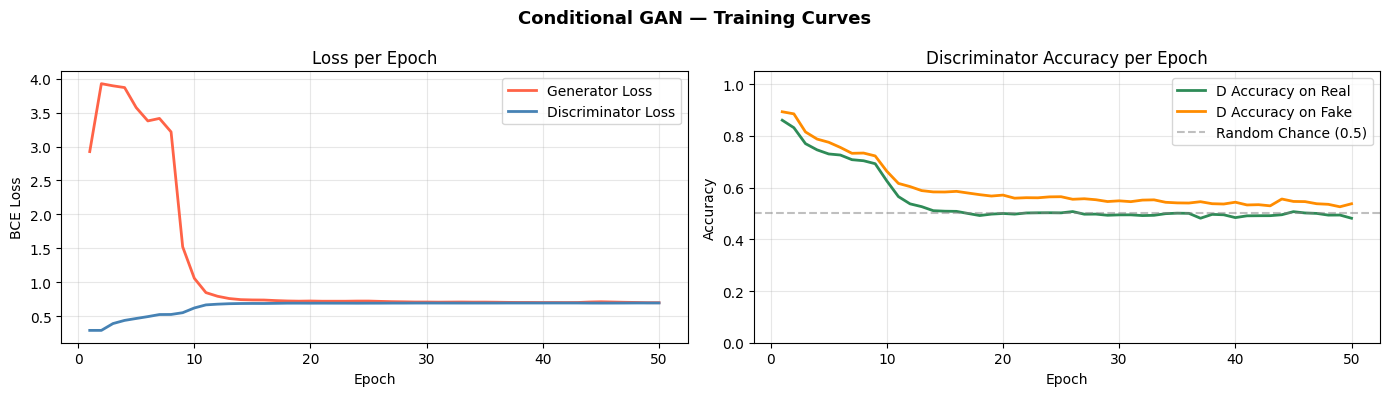

Final Generator Loss     : 0.6969
Final Discriminator Loss : 0.6931
D Accuracy on Real       : 0.482
D Accuracy on Fake       : 0.538


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Conditional GAN — Training Curves', fontsize=13, fontweight='bold')

ax1.plot(epochs_range, CGAN_G_losses, label='Generator Loss',     color='tomato',    linewidth=2)
ax1.plot(epochs_range, CGAN_D_losses, label='Discriminator Loss', color='steelblue', linewidth=2)
ax1.set_title('Loss per Epoch')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, CGAN_D_real_accs, label='D Accuracy on Real', color='seagreen',  linewidth=2)
ax2.plot(epochs_range, CGAN_D_fake_accs, label='D Accuracy on Fake', color='darkorange', linewidth=2)
ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random Chance (0.5)')
ax2.set_title('Discriminator Accuracy per Epoch')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.05)
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final Generator Loss     : {CGAN_G_losses[-1]:.4f}')
print(f'Final Discriminator Loss : {CGAN_D_losses[-1]:.4f}')
print(f'D Accuracy on Real       : {CGAN_D_real_accs[-1]:.3f}')
print(f'D Accuracy on Fake       : {CGAN_D_fake_accs[-1]:.3f}')

## Step 11: Side-by-Side Comparison — GAN vs cGAN

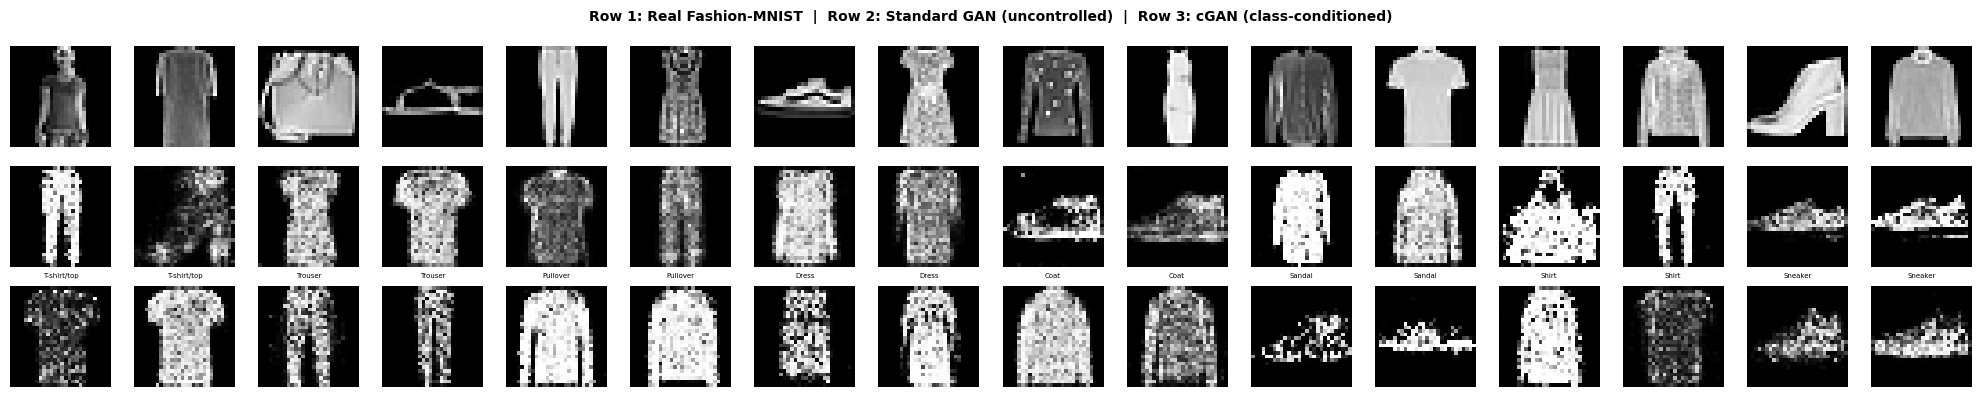

In [ ]:
real_sample, real_sample_cls = next(iter(train_loader))
generator.eval()
with torch.no_grad():
    z = torch.randn(16, LATENT_DIM, device=DEVICE)
    gan_imgs = generator(z).cpu()

cgan_generator.eval()
with torch.no_grad():
    demo_z = torch.randn(16, LATENT_DIM, device=DEVICE)
    demo_labels = torch.arange(NUM_CLASSES, device=DEVICE).repeat_interleave(2)[:16]
    cgan_imgs = cgan_generator(demo_z, demo_labels).cpu()

fig, axes = plt.subplots(3, 16, figsize=(20, 4))
fig.suptitle(
    'Row 1: Real Fashion-MNIST  |  '
    'Row 2: Standard GAN (uncontrolled)  |  '
    'Row 3: cGAN (class-conditioned)',
    fontsize=10, fontweight='bold'
)

for i in range(16):
    axes[0, i].imshow(real_sample[i].squeeze().numpy(), cmap='gray')
    axes[0, i].axis('off')

    axes[1, i].imshow(gan_imgs[i].squeeze().numpy(), cmap='gray')
    axes[1, i].axis('off')

    axes[2, i].imshow(cgan_imgs[i].squeeze().numpy(), cmap='gray')
    axes[2, i].set_title(CLASS_NAMES[demo_labels[i].item()], fontsize=5)
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Real',     fontsize=9, fontweight='bold')
axes[1, 0].set_ylabel('GAN',      fontsize=9, fontweight='bold')
axes[2, 0].set_ylabel('cGAN',     fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### Experiment-1: Latent Size

Training cGAN with latent_dim=16...
  Epoch 1/15
  Epoch 2/15
  Epoch 3/15
  Epoch 4/15
  Epoch 5/15
  Epoch 6/15
  Epoch 7/15
  Epoch 8/15
  Epoch 9/15
  Epoch 10/15
  Epoch 11/15
  Epoch 12/15
  Epoch 13/15
  Epoch 14/15
  Epoch 15/15
  Sharpness: 2.05531
Training cGAN with latent_dim=32...
  Epoch 1/15
  Epoch 2/15
  Epoch 3/15
  Epoch 4/15
  Epoch 5/15
  Epoch 6/15
  Epoch 7/15
  Epoch 8/15
  Epoch 9/15
  Epoch 10/15
  Epoch 11/15
  Epoch 12/15
  Epoch 13/15
  Epoch 14/15
  Epoch 15/15
  Sharpness: 1.72209
Training cGAN with latent_dim=64...
  Epoch 1/15
  Epoch 2/15
  Epoch 3/15
  Epoch 4/15
  Epoch 5/15
  Epoch 6/15
  Epoch 7/15
  Epoch 8/15
  Epoch 9/15
  Epoch 10/15
  Epoch 11/15
  Epoch 12/15
  Epoch 13/15
  Epoch 14/15
  Epoch 15/15
  Sharpness: 2.53696
Training cGAN with latent_dim=100...
  Epoch 1/15
  Epoch 2/15
  Epoch 3/15
  Epoch 4/15
  Epoch 5/15
  Epoch 6/15
  Epoch 7/15
  Epoch 8/15
  Epoch 9/15
  Epoch 10/15
  Epoch 11/15
  Epoch 12/15
  Epoch 13/15
  Epoch 14/15
  

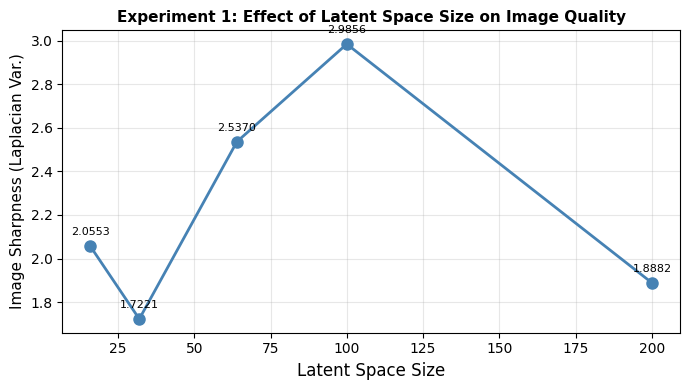


Conclusion — Exp 1: Larger latent dims generally allow richer variation,
but beyond a threshold (e.g. 100), gains are marginal and training may destabilize.


In [ ]:
def image_sharpness(imgs):
    import torch.nn.functional as F
    laplacian_kernel = torch.tensor([[0,1,0],[1,-4,1],[0,1,0]],
                                     dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    sharpness_scores = []
    for img in imgs:
        img_t = img.unsqueeze(0)
        lap = F.conv2d(img_t, laplacian_kernel, padding=1)
        sharpness_scores.append(lap.var().item())
    return np.mean(sharpness_scores)

latent_sizes = [16, 32, 64, 100, 200]
exp1_sharpness = []
exp1_images = {}

for ld in latent_sizes:
    print(f"Training cGAN with latent_dim={ld}...")
    g_exp = ConditionalGenerator(ld, NUM_CLASSES).to(DEVICE)
    d_exp = ConditionalDiscriminator(NUM_CLASSES).to(DEVICE)
    opt_g = torch.optim.Adam(g_exp.parameters(), lr=0.0002, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(d_exp.parameters(), lr=0.0002, betas=(0.5, 0.999))
    crit  = nn.BCELoss()

    for epoch in range(15):
        print(f"  Epoch {epoch+1}/15")
        for real_imgs, real_cls in train_loader:
            bs = real_imgs.size(0)
            real_imgs = real_imgs.to(DEVICE)
            real_cls  = real_cls.to(DEVICE)
            real_lbl  = torch.ones(bs, 1, device=DEVICE)
            fake_lbl  = torch.zeros(bs, 1, device=DEVICE)
            opt_d.zero_grad()
            z = torch.randn(bs, ld, device=DEVICE)
            fc = torch.randint(0, NUM_CLASSES, (bs,), device=DEVICE)
            fi = g_exp(z, fc).detach()
            loss_d = (crit(d_exp(real_imgs, real_cls), real_lbl) +
                      crit(d_exp(fi, fc), fake_lbl)) / 2
            loss_d.backward(); opt_d.step()
            opt_g.zero_grad()
            z = torch.randn(bs, ld, device=DEVICE)
            gc = torch.randint(0, NUM_CLASSES, (bs,), device=DEVICE)
            gi = g_exp(z, gc)
            loss_g = crit(d_exp(gi, gc), real_lbl)
            loss_g.backward(); opt_g.step()

    g_exp.eval()
    with torch.no_grad():
        z = torch.randn(NUM_CLASSES, ld, device=DEVICE)
        lbl = torch.arange(NUM_CLASSES, dtype=torch.long, device=DEVICE)
        imgs = g_exp(z, lbl).cpu()
    exp1_images[ld] = imgs
    exp1_sharpness.append(image_sharpness(imgs))
    print(f"  Sharpness: {exp1_sharpness[-1]:.5f}")

plt.figure(figsize=(7, 4))
plt.plot(latent_sizes, exp1_sharpness, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.xlabel('Latent Space Size', fontsize=12)
plt.ylabel('Image Sharpness (Laplacian Var.)', fontsize=11)
plt.title('Experiment 1: Effect of Latent Space Size on Image Quality', fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3)
for x, y in zip(latent_sizes, exp1_sharpness):
    plt.annotate(f'{y:.4f}', (x, y), textcoords="offset points", xytext=(0, 8), fontsize=8, ha='center')
plt.tight_layout()
plt.savefig('exp1_latent_size.png', dpi=150)
plt.show()
print("\nConclusion — Exp 1: Larger latent dims generally allow richer variation,")
print("but beyond a threshold (e.g. 100), gains are marginal and training may destabilize.")

### Experiment-2: Effect of Embedding

Training cGAN with emb_dim=4...
  Epoch 1/15
  Epoch 2/15
  Epoch 3/15
  Epoch 4/15
  Epoch 5/15
  Epoch 6/15
  Epoch 7/15
  Epoch 8/15
  Epoch 9/15
  Epoch 10/15
  Epoch 11/15
  Epoch 12/15
  Epoch 13/15
  Epoch 14/15
  Epoch 15/15
  Sharpness: 2.85360
Training cGAN with emb_dim=8...
  Epoch 1/15
  Epoch 2/15
  Epoch 3/15
  Epoch 4/15
  Epoch 5/15
  Epoch 6/15
  Epoch 7/15
  Epoch 8/15
  Epoch 9/15
  Epoch 10/15
  Epoch 11/15
  Epoch 12/15
  Epoch 13/15
  Epoch 14/15
  Epoch 15/15
  Sharpness: 3.49944
Training cGAN with emb_dim=16...
  Epoch 1/15
  Epoch 2/15
  Epoch 3/15
  Epoch 4/15
  Epoch 5/15
  Epoch 6/15
  Epoch 7/15
  Epoch 8/15
  Epoch 9/15
  Epoch 10/15
  Epoch 11/15
  Epoch 12/15
  Epoch 13/15
  Epoch 14/15
  Epoch 15/15
  Sharpness: 2.94871
Training cGAN with emb_dim=32...
  Epoch 1/15
  Epoch 2/15
  Epoch 3/15
  Epoch 4/15
  Epoch 5/15
  Epoch 6/15
  Epoch 7/15
  Epoch 8/15
  Epoch 9/15
  Epoch 10/15
  Epoch 11/15
  Epoch 12/15
  Epoch 13/15
  Epoch 14/15
  Epoch 15/15
  S

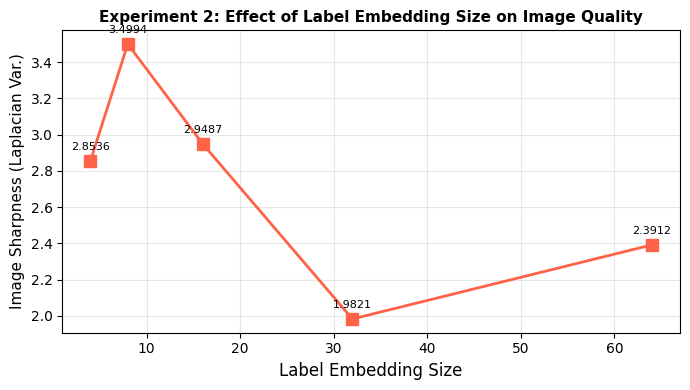


Conclusion — Exp 2: Very small embeddings (4, 8) under-represent class info.
Medium sizes (16–32) typically balance expressiveness vs. noise injection.


In [ ]:
class ConditionalGeneratorEmbVar(nn.Module):
    def __init__(self, latent_dim=100, num_classes=10, emb_dim=10):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, emb_dim)
        self.model = nn.Sequential(
            nn.Linear(latent_dim + emb_dim, 256), nn.LeakyReLU(0.2), nn.BatchNorm1d(256, momentum=0.8),
            nn.Linear(256, 512),  nn.LeakyReLU(0.2), nn.BatchNorm1d(512, momentum=0.8),
            nn.Linear(512, 1024), nn.LeakyReLU(0.2), nn.BatchNorm1d(1024, momentum=0.8),
            nn.Linear(1024, 784), nn.Tanh()
        )
    def forward(self, z, labels):
        x = torch.cat([z, self.label_emb(labels)], dim=1)
        return self.model(x).view(x.size(0), 1, 28, 28)

emb_sizes  = [4, 8, 16, 32, 64]
exp2_sharp = []
exp2_images = {}

for emb in emb_sizes:
    print(f"Training cGAN with emb_dim={emb}...")
    g_exp2 = ConditionalGeneratorEmbVar(LATENT_DIM, NUM_CLASSES, emb).to(DEVICE)
    d_exp2 = ConditionalDiscriminator(NUM_CLASSES).to(DEVICE)
    opt_g2 = torch.optim.Adam(g_exp2.parameters(), lr=0.0002, betas=(0.5, 0.999))
    opt_d2 = torch.optim.Adam(d_exp2.parameters(), lr=0.0002, betas=(0.5, 0.999))
    crit2  = nn.BCELoss()

    for epoch in range(15):
        print(f"  Epoch {epoch+1}/15")
        for real_imgs, real_cls in train_loader:
            bs = real_imgs.size(0)
            real_imgs = real_imgs.to(DEVICE); real_cls = real_cls.to(DEVICE)
            rl = torch.ones(bs, 1, device=DEVICE); fl = torch.zeros(bs, 1, device=DEVICE)
            opt_d2.zero_grad()
            z = torch.randn(bs, LATENT_DIM, device=DEVICE)
            fc = torch.randint(0, NUM_CLASSES, (bs,), device=DEVICE)
            fi = g_exp2(z, fc).detach()
            loss_d = (crit2(d_exp2(real_imgs, real_cls), rl) + crit2(d_exp2(fi, fc), fl)) / 2
            loss_d.backward(); opt_d2.step()
            opt_g2.zero_grad()
            z = torch.randn(bs, LATENT_DIM, device=DEVICE)
            gc = torch.randint(0, NUM_CLASSES, (bs,), device=DEVICE)
            gi = g_exp2(z, gc)
            loss_g = crit2(d_exp2(gi, gc), rl)
            loss_g.backward(); opt_g2.step()

    g_exp2.eval()
    with torch.no_grad():
        z = torch.randn(NUM_CLASSES, LATENT_DIM, device=DEVICE)
        lbl = torch.arange(NUM_CLASSES, dtype=torch.long, device=DEVICE)
        imgs = g_exp2(z, lbl).cpu()
    exp2_images[emb] = imgs
    exp2_sharp.append(image_sharpness(imgs))
    print(f"  Sharpness: {exp2_sharp[-1]:.5f}")

plt.figure(figsize=(7, 4))
plt.plot(emb_sizes, exp2_sharp, 's-', color='tomato', linewidth=2, markersize=8)
plt.xlabel('Label Embedding Size', fontsize=12)
plt.ylabel('Image Sharpness (Laplacian Var.)', fontsize=11)
plt.title('Experiment 2: Effect of Label Embedding Size on Image Quality', fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3)
for x, y in zip(emb_sizes, exp2_sharp):
    plt.annotate(f'{y:.4f}', (x, y), textcoords="offset points", xytext=(0, 8), fontsize=8, ha='center')
plt.tight_layout()
plt.savefig('exp2_emb_size.png', dpi=150)
plt.show()
print("\nConclusion — Exp 2: Very small embeddings (4, 8) under-represent class info.")
print("Medium sizes (16–32) typically balance expressiveness vs. noise injection.")

### Experiment-3: Label injection at different layers


Training: Label @ Input
  Epoch 1/15
  Epoch 2/15
  Epoch 3/15
  Epoch 4/15
  Epoch 5/15
  Epoch 6/15
  Epoch 7/15
  Epoch 8/15
  Epoch 9/15
  Epoch 10/15
  Epoch 11/15
  Epoch 12/15
  Epoch 13/15
  Epoch 14/15
  Epoch 15/15
  Sharpness: 2.98998

Training: Label @ Middle
  Epoch 1/15
  Epoch 2/15
  Epoch 3/15
  Epoch 4/15
  Epoch 5/15
  Epoch 6/15
  Epoch 7/15
  Epoch 8/15
  Epoch 9/15
  Epoch 10/15
  Epoch 11/15
  Epoch 12/15
  Epoch 13/15
  Epoch 14/15
  Epoch 15/15
  Sharpness: 2.88018

Training: Label @ End
  Epoch 1/15
  Epoch 2/15
  Epoch 3/15
  Epoch 4/15
  Epoch 5/15
  Epoch 6/15
  Epoch 7/15
  Epoch 8/15
  Epoch 9/15
  Epoch 10/15
  Epoch 11/15
  Epoch 12/15
  Epoch 13/15
  Epoch 14/15
  Epoch 15/15
  Sharpness: 2.78905


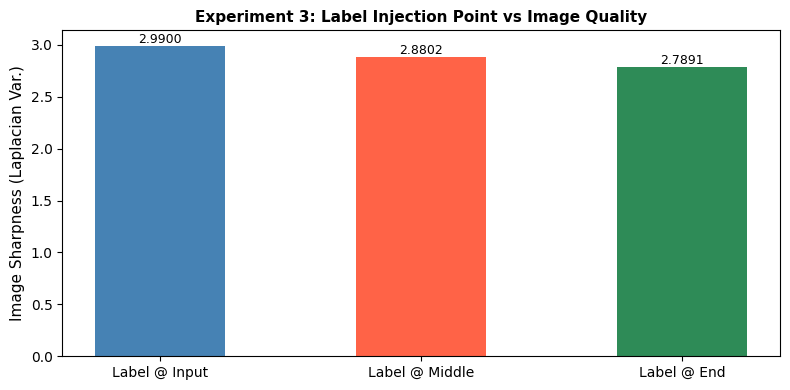


Conclusion — Exp 3: Early injection (at input) gives the generator full context
throughout all layers. Mid/late injection can lead to weaker class conditioning.


In [ ]:
class GenLabelAtMiddle(nn.Module):
    def __init__(self, latent_dim=100, num_classes=10):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.layer1 = nn.Sequential(nn.Linear(latent_dim, 256), nn.LeakyReLU(0.2), nn.BatchNorm1d(256, momentum=0.8))
        self.layer2 = nn.Sequential(nn.Linear(256 + num_classes, 512), nn.LeakyReLU(0.2), nn.BatchNorm1d(512, momentum=0.8))
        self.layer3 = nn.Sequential(nn.Linear(512, 1024), nn.LeakyReLU(0.2), nn.BatchNorm1d(1024, momentum=0.8))
        self.out    = nn.Sequential(nn.Linear(1024, 784), nn.Tanh())
    def forward(self, z, labels):
        emb = self.label_emb(labels)
        x = self.layer1(z)
        x = self.layer2(torch.cat([x, emb], dim=1))
        x = self.layer3(x)
        return self.out(x).view(z.size(0), 1, 28, 28)

class GenLabelAtEnd(nn.Module):
    def __init__(self, latent_dim=100, num_classes=10):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.backbone  = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.LeakyReLU(0.2), nn.BatchNorm1d(256, momentum=0.8),
            nn.Linear(256, 512),  nn.LeakyReLU(0.2), nn.BatchNorm1d(512, momentum=0.8),
            nn.Linear(512, 1024), nn.LeakyReLU(0.2), nn.BatchNorm1d(1024, momentum=0.8),
        )
        self.out = nn.Sequential(nn.Linear(1024 + num_classes, 784), nn.Tanh())
    def forward(self, z, labels):
        x = self.backbone(z)
        return self.out(torch.cat([x, self.label_emb(labels)], dim=1)).view(z.size(0), 1, 28, 28)

configs = {
    'Label @ Input':  ConditionalGenerator(LATENT_DIM, NUM_CLASSES),
    'Label @ Middle': GenLabelAtMiddle(LATENT_DIM, NUM_CLASSES),
    'Label @ End':    GenLabelAtEnd(LATENT_DIM, NUM_CLASSES),
}

exp3_sharp  = {}
exp3_images = {}

for name, gen_model in configs.items():
    print(f"\nTraining: {name}")
    gen_model = gen_model.to(DEVICE)
    d_exp3 = ConditionalDiscriminator(NUM_CLASSES).to(DEVICE)
    opt_g3 = torch.optim.Adam(gen_model.parameters(), lr=0.0002, betas=(0.5, 0.999))
    opt_d3 = torch.optim.Adam(d_exp3.parameters(),   lr=0.0002, betas=(0.5, 0.999))
    crit3  = nn.BCELoss()

    for epoch in range(15):
        print(f"  Epoch {epoch+1}/15")
        for real_imgs, real_cls in train_loader:
            bs = real_imgs.size(0)
            real_imgs = real_imgs.to(DEVICE); real_cls = real_cls.to(DEVICE)
            rl = torch.ones(bs, 1, device=DEVICE); fl = torch.zeros(bs, 1, device=DEVICE)
            opt_d3.zero_grad()
            z = torch.randn(bs, LATENT_DIM, device=DEVICE)
            fc = torch.randint(0, NUM_CLASSES, (bs,), device=DEVICE)
            fi = gen_model(z, fc).detach()
            ld = (crit3(d_exp3(real_imgs, real_cls), rl) + crit3(d_exp3(fi, fc), fl)) / 2
            ld.backward(); opt_d3.step()
            opt_g3.zero_grad()
            z = torch.randn(bs, LATENT_DIM, device=DEVICE)
            gc = torch.randint(0, NUM_CLASSES, (bs,), device=DEVICE)
            gi = gen_model(z, gc)
            lg = crit3(d_exp3(gi, gc), rl)
            lg.backward(); opt_g3.step()

    gen_model.eval()
    with torch.no_grad():
        z = torch.randn(NUM_CLASSES, LATENT_DIM, device=DEVICE)
        lbl = torch.arange(NUM_CLASSES, dtype=torch.long, device=DEVICE)
        imgs = gen_model(z, lbl).cpu()
    exp3_images[name] = imgs
    exp3_sharp[name]  = image_sharpness(imgs)
    print(f"  Sharpness: {exp3_sharp[name]:.5f}")

plt.figure(figsize=(8, 4))
bars = plt.bar(exp3_sharp.keys(), exp3_sharp.values(),
               color=['steelblue', 'tomato', 'seagreen'], width=0.5)
plt.ylabel('Image Sharpness (Laplacian Var.)', fontsize=11)
plt.title('Experiment 3: Label Injection Point vs Image Quality', fontsize=11, fontweight='bold')
for bar, v in zip(bars, exp3_sharp.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
             f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('exp3_label_injection.png', dpi=150)
plt.show()
print("\nConclusion — Exp 3: Early injection (at input) gives the generator full context")
print("throughout all layers. Mid/late injection can lead to weaker class conditioning.")

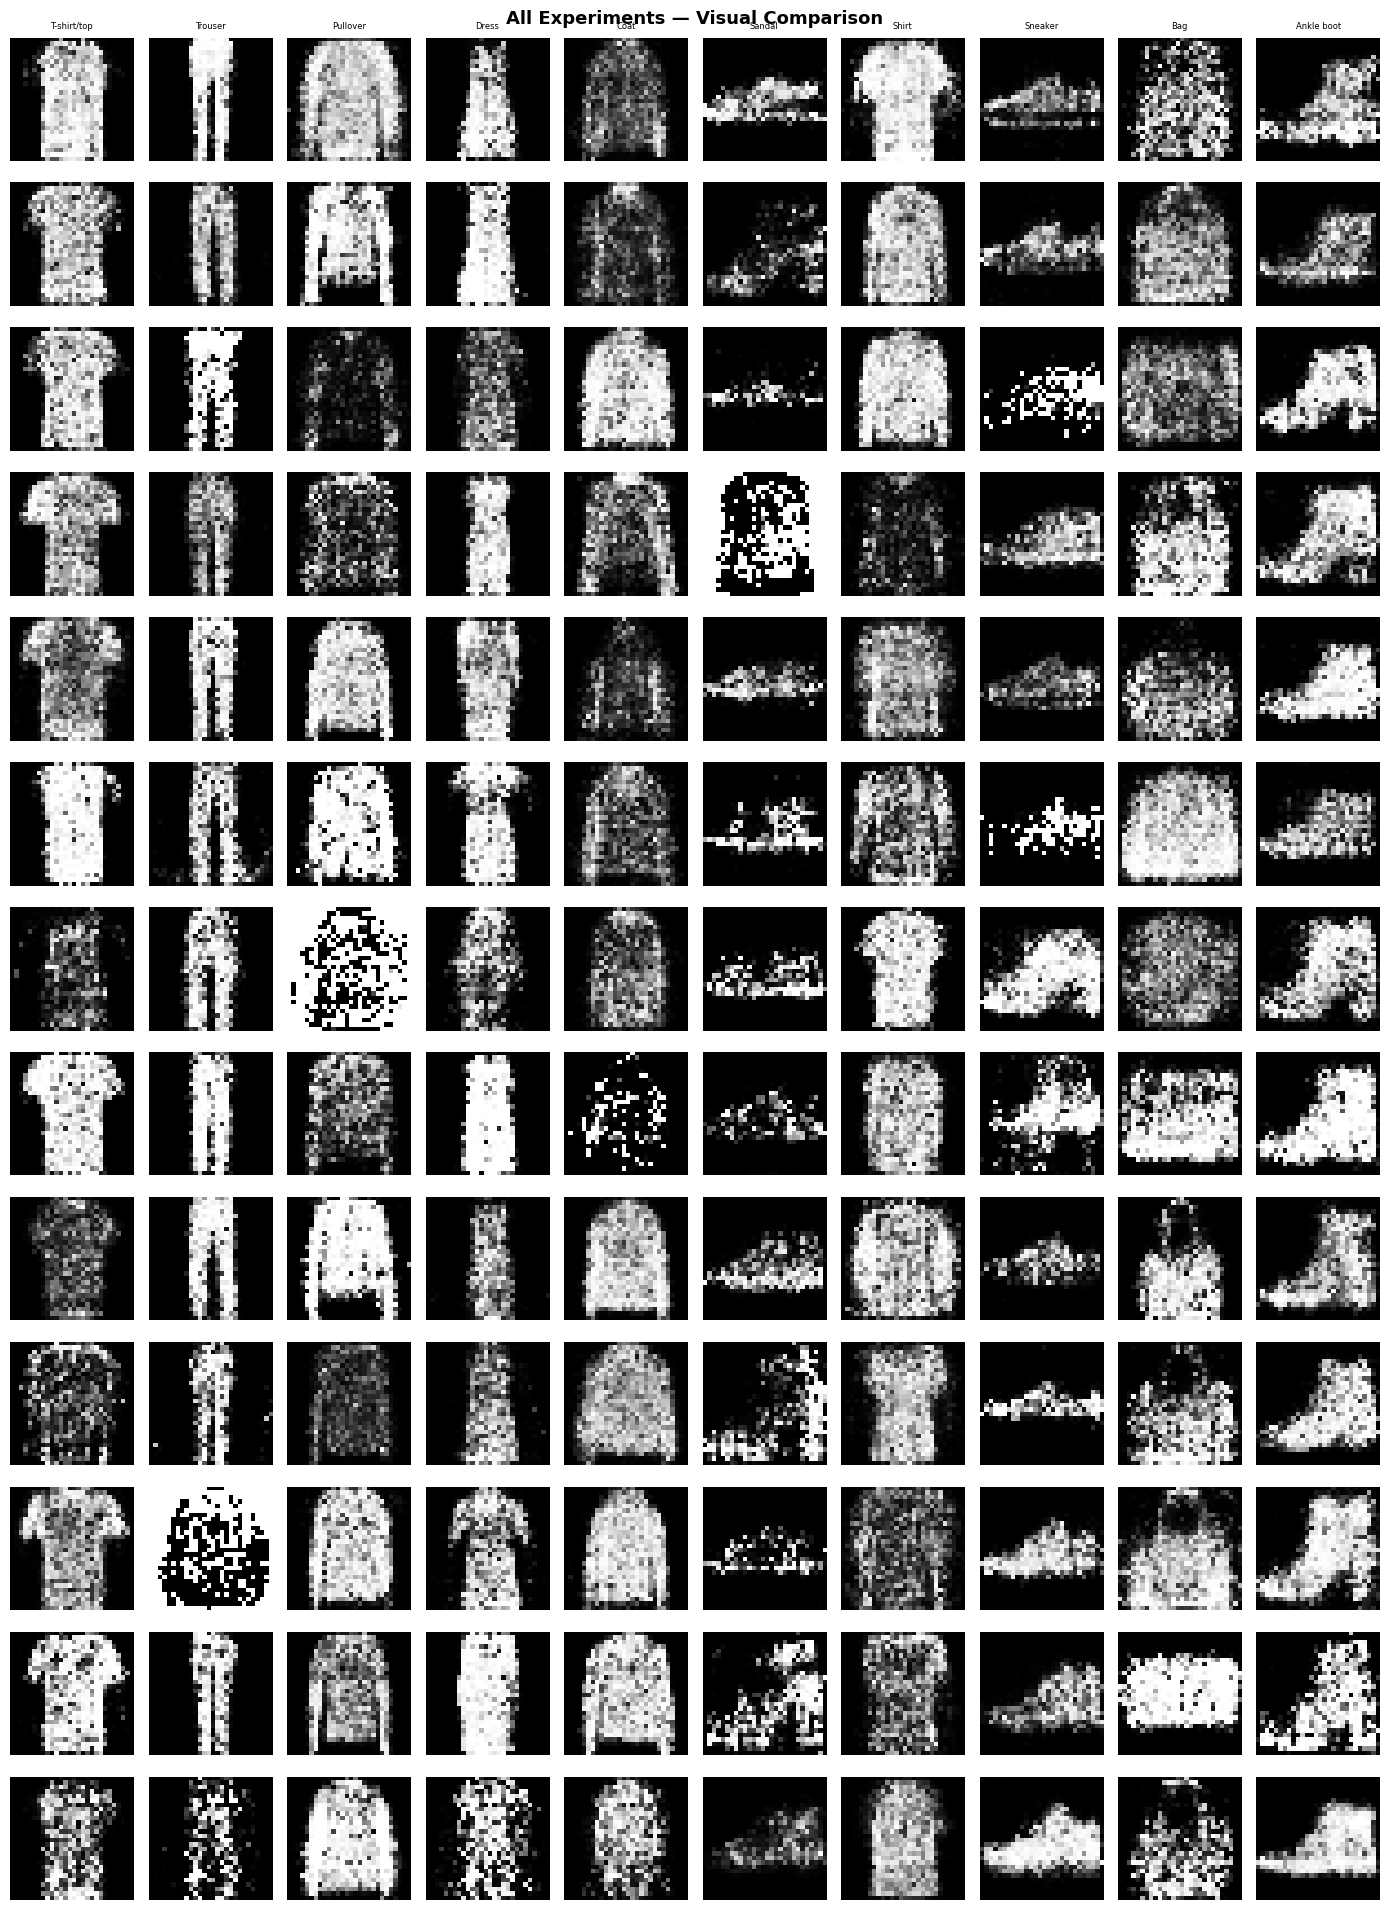

In [ ]:

total_rows = len(latent_sizes) + len(emb_sizes) + len(configs)
fig, axes = plt.subplots(total_rows, NUM_CLASSES, figsize=(14, total_rows * 1.5))
fig.suptitle('All Experiments — Visual Comparison', fontsize=13, fontweight='bold')

row = 0

for ld in latent_sizes:
    for col in range(NUM_CLASSES):
        axes[row, col].imshow(exp1_images[ld][col].squeeze().numpy(), cmap='gray')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(CLASS_NAMES[col], fontsize=6)
    axes[row, 0].set_ylabel(f'Exp1 z={ld}', fontsize=7, fontweight='bold')
    row += 1

for emb in emb_sizes:
    for col in range(NUM_CLASSES):
        axes[row, col].imshow(exp2_images[emb][col].squeeze().numpy(), cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'Exp2 emb={emb}', fontsize=7, fontweight='bold')
    row += 1

for name in configs.keys():
    for col in range(NUM_CLASSES):
        axes[row, col].imshow(exp3_images[name][col].squeeze().numpy(), cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'Exp3 {name}', fontsize=7, fontweight='bold')
    row += 1

plt.tight_layout()
plt.savefig('all_experiments_visual.png', dpi=150, bbox_inches='tight')
plt.show()